# Phase 3 — Time-Series Forecasting

## 1. Introduction

**Phase 1** (`sales_analytics_pipeline.ipynb`) created **`fact_sales`** in PostgreSQL. **Phase 2** explored seasonality and advanced analytics.

**Phase 3** builds a complete forecasting workflow on **daily revenue** aggregated from `fact_sales`:

- Classical models: **ARIMA** and **Prophet**
- Deep learning: **LSTM**
- Evaluation: **MAE**, **RMSE**, **MAPE**
- Concepts: trend, seasonality, stationarity, time-based train/test split, rolling forecast

> **Prerequisite:** Phase 1 completed; `fact_sales` populated in `sales_db`.


## 2. Library Imports & PostgreSQL Connection

In [18]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sqlalchemy import create_engine, text
from sqlalchemy.engine import Engine

# Classical time series
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

# Prophet (optional)
try:
    from prophet import Prophet
    HAS_PROPHET = True
except ImportError:
    HAS_PROPHET = False
    warnings.warn("prophet not installed; Prophet section will be skipped.")

# Auto-ARIMA (optional)
try:
    import pmdarima as pm
    HAS_PMDARIMA = True
except ImportError:
    HAS_PMDARIMA = False
    warnings.warn("pmdarima not installed; using manual ARIMA order (1,1,1).")

# Deep learning
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    HAS_TF = True
    tf.random.set_seed(42)
except ImportError:
    HAS_TF = False
    warnings.warn("tensorflow not installed; LSTM section will be skipped.")

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

# PostgreSQL — match Phase 1/2 (set env vars or edit placeholders)
PG_USER = os.environ.get("PGUSER", "postgres")
PG_PASSWORD = os.environ.get("PGPASSWORD", "kanna")
PG_HOST = os.environ.get("PGHOST", "localhost")
PG_PORT = os.environ.get("PGPORT", "5432")
PG_DATABASE = os.environ.get("PGDATABASE", "sales_db")

CONNECTION_STRING = os.environ.get(
    "DATABASE_URL",
    f"postgresql+psycopg2://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DATABASE}",
)

engine: Engine = create_engine(CONNECTION_STRING)


def run_sql(sql: str) -> pd.DataFrame:
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)


print("Libraries loaded. Prophet:", HAS_PROPHET, "| pmdarima:", HAS_PMDARIMA, "| TensorFlow:", HAS_TF)


Libraries loaded. Prophet: True | pmdarima: True | TensorFlow: True


## 3. Load Time-Series Data

Daily revenue is aggregated from `fact_sales` and indexed by `order_date`.


Date range: 2016-09-04 → 2018-09-03 | 730 days


,daily_revenue
order_date,
2016-09-04,72.890
2016-09-05,59.500
2016-09-06,67.047
2016-09-07,74.594
2016-09-08,82.141


,daily_revenue
count,730.000000
mean,18815.622068
std,13824.804395
min,10.900000
25%,8336.267500
50%,18151.685000
75%,28082.877500
max,152653.740000


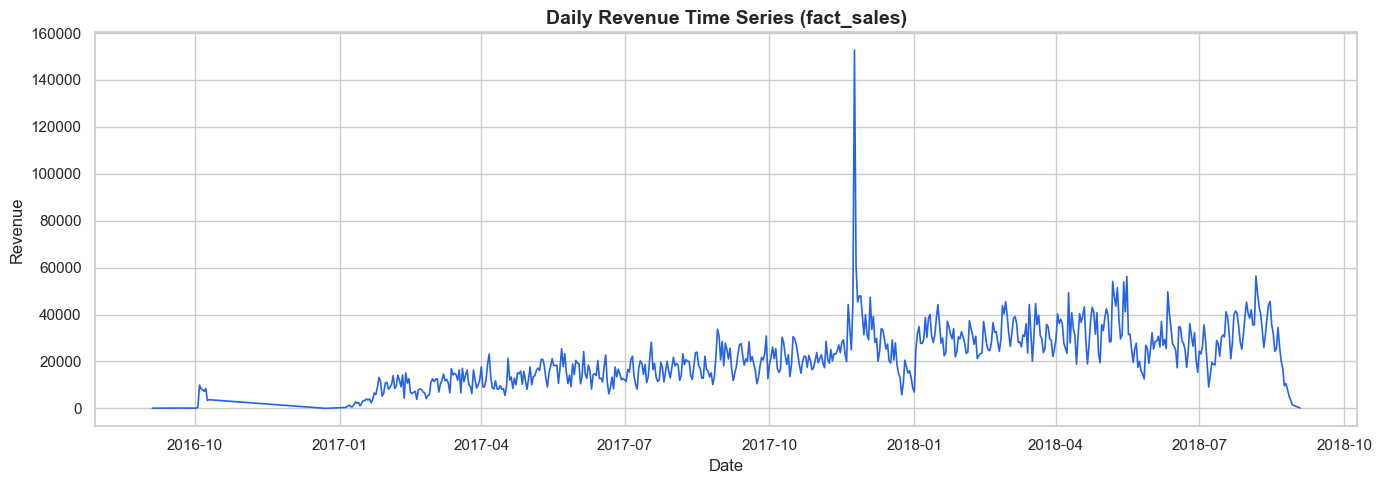

In [10]:
DAILY_REVENUE_SQL = '''
SELECT order_date, SUM(total_revenue) AS daily_revenue
FROM fact_sales
GROUP BY order_date
ORDER BY order_date;
'''

raw = run_sql(DAILY_REVENUE_SQL)
raw["order_date"] = pd.to_datetime(raw["order_date"])
ts = raw.set_index("order_date").sort_index()
ts = ts.asfreq("D")  # daily frequency
ts["daily_revenue"] = ts["daily_revenue"].interpolate(method="time").ffill().bfill()

print(f"Date range: {ts.index.min().date()} → {ts.index.max().date()} | {len(ts)} days")
display(ts.head())
display(ts.describe())

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts.index, ts["daily_revenue"], color="#2563eb", lw=1.2)
ax.set_title("Daily Revenue Time Series (fact_sales)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
plt.tight_layout()
plt.show()


## 4. Time-Series Concepts

| Component | Meaning |
|-----------|---------|
| **Trend** | Long-run increase or decrease in revenue |
| **Seasonality** | Repeating patterns (weekly, yearly) |
| **Stationarity** | Constant mean/variance over time; required for many ARIMA assumptions |

We inspect rolling statistics and run the **Augmented Dickey–Fuller (ADF)** test. If the series is non-stationary, we apply **differencing** for analysis and ARIMA.


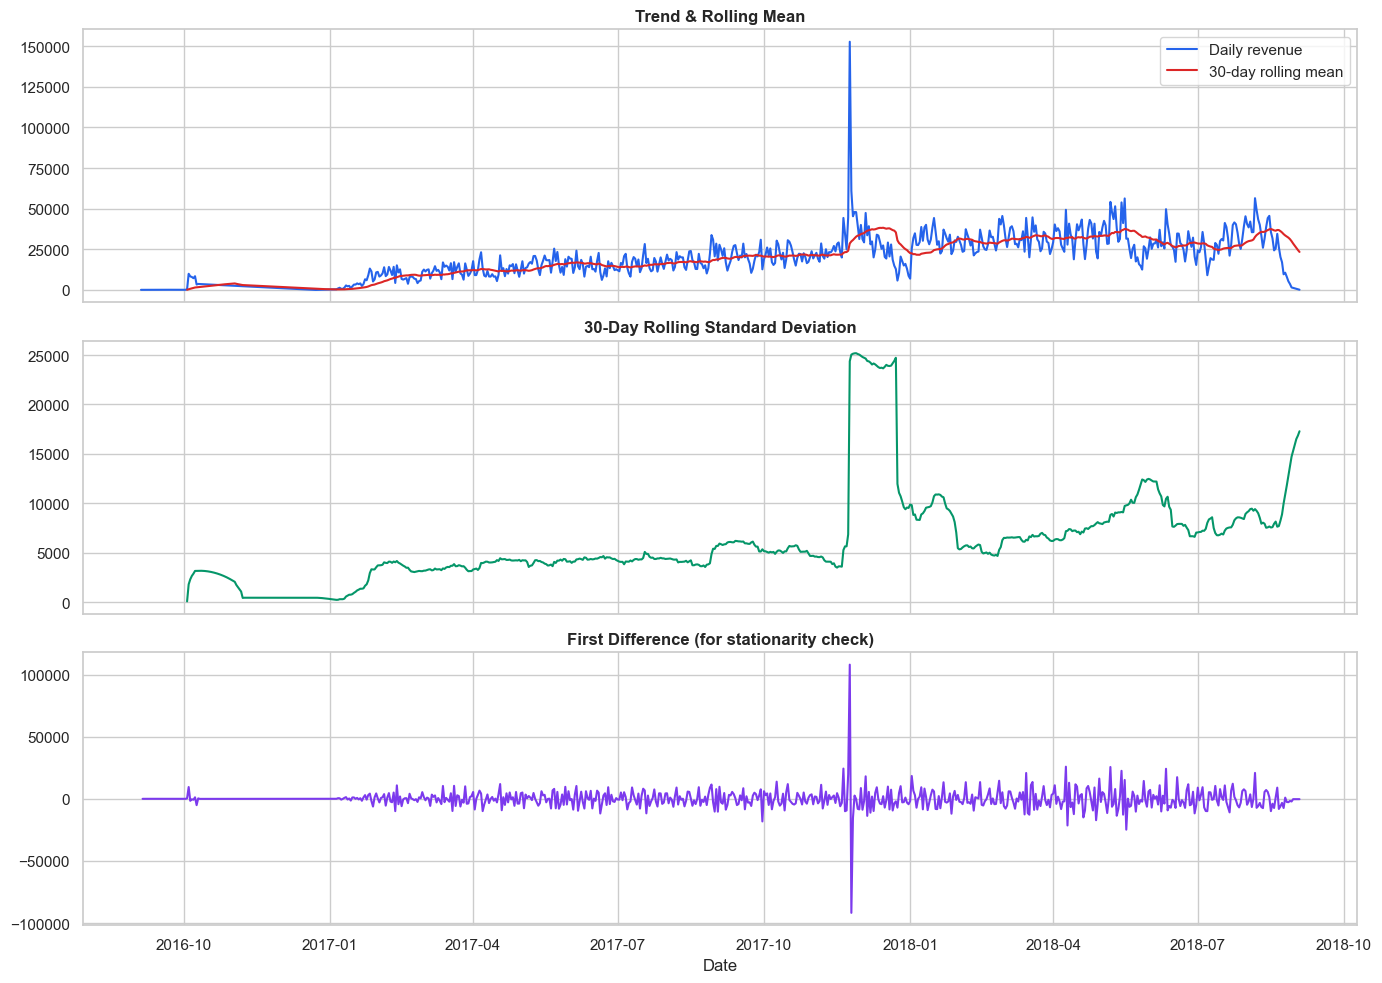

ADF — levels
  Statistic: -2.2562  |  p-value: 0.1865
  Non-stationary at α=0.05
ADF — first difference
  Statistic: -7.8811  |  p-value: 0.0000
  Stationary at α=0.05

ARIMA will use d≥1: True


In [19]:
series = ts["daily_revenue"].copy()
window = 30

roll_mean = series.rolling(window=window).mean()
roll_std = series.rolling(window=window).std()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(series.index, series.values, label="Daily revenue", color="#2563eb")
axes[0].plot(roll_mean.index, roll_mean.values, label=f"{window}-day rolling mean", color="#dc2626")
axes[0].set_title("Trend & Rolling Mean", fontweight="bold")
axes[0].legend()

axes[1].plot(roll_std.index, roll_std.values, color="#059669")
axes[1].set_title(f"{window}-Day Rolling Standard Deviation", fontweight="bold")

diff1 = series.diff().dropna()
axes[2].plot(diff1.index, diff1.values, color="#7c3aed")
axes[2].set_title("First Difference (for stationarity check)", fontweight="bold")
axes[2].set_xlabel("Date")
plt.tight_layout()
plt.show()

def adf_report(x: pd.Series, label: str) -> float:
    result = adfuller(x.dropna(), autolag="AIC")
    print(f"ADF — {label}")
    print(f"  Statistic: {result[0]:.4f}  |  p-value: {result[1]:.4f}")
    print(f"  {'Stationary' if result[1] < 0.05 else 'Non-stationary'} at α=0.05")
    return result[1]

p_level = adf_report(series, "levels")
p_diff = adf_report(diff1, "first difference")

USE_DIFF_FOR_ARIMA = p_level >= 0.05
print(f"\nARIMA will use d≥1: {USE_DIFF_FOR_ARIMA}")


## 5. Train-Test Split (Time-Based)

The last **90 days** are held out for testing. No random shuffling — preserves temporal order.


Train: 640 days | Test: 90 days | Split at 2018-06-06


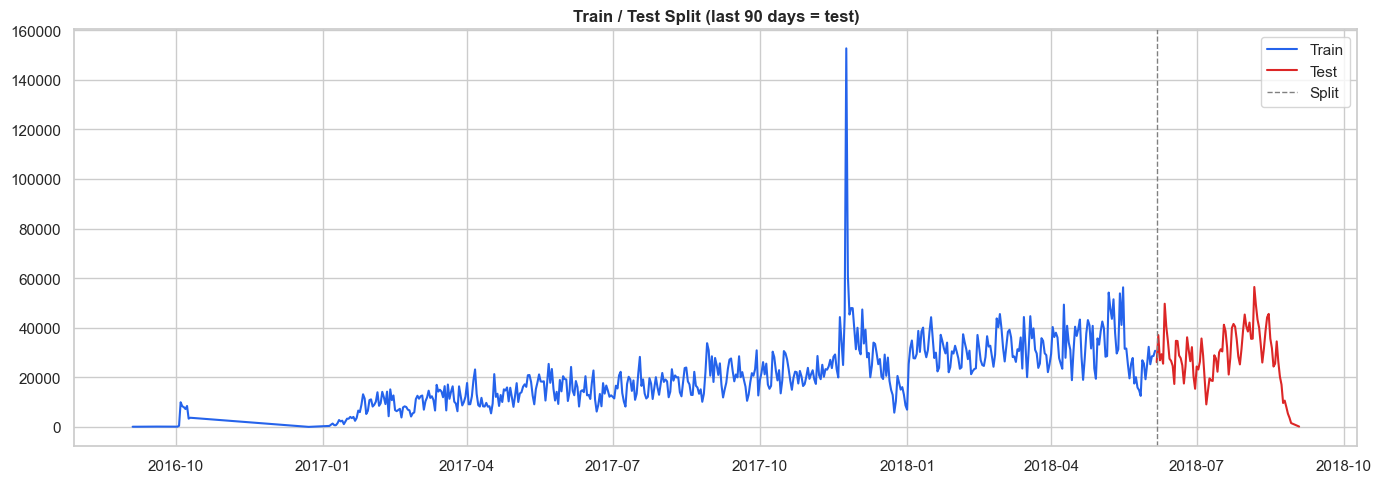

In [20]:
TEST_DAYS = 90
FORECAST_HORIZON = 90  # align test length with forecast horizon

if len(ts) <= TEST_DAYS + 30:
    raise ValueError("Not enough history; need more than 120 daily observations.")

train = ts.iloc[:-TEST_DAYS].copy()
test = ts.iloc[-TEST_DAYS:].copy()
y_train = train["daily_revenue"]
y_test = test["daily_revenue"]

split_date = test.index[0]
print(f"Train: {len(train)} days | Test: {len(test)} days | Split at {split_date.date()}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_train.index, y_train.values, label="Train", color="#2563eb")
ax.plot(y_test.index, y_test.values, label="Test", color="#dc2626")
ax.axvline(split_date, color="gray", ls="--", lw=1, label="Split")
ax.set_title("Train / Test Split (last 90 days = test)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


In [21]:
def mae(y_true, y_pred) -> float:
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred)))


def rmse(y_true, y_pred) -> float:
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = np.abs(y_true) > eps
    if mask.sum() == 0:
        return float("nan")
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


def evaluate(y_true, y_pred, model_name: str) -> dict:
    return {
        "model": model_name,
        "MAE": round(mae(y_true, y_pred), 2),
        "RMSE": round(rmse(y_true, y_pred), 2),
        "MAPE (%)": round(mape(y_true, y_pred), 2),
    }


metrics_rows = []


## 6. Classical Forecasting Models

### 6A. ARIMA Model

Fit on training data; forecast the test period. Order selected via `pmdarima.auto_arima` when available, else **ARIMA(1,1,1)**.


auto_arima selected order: (0, 1, 2)


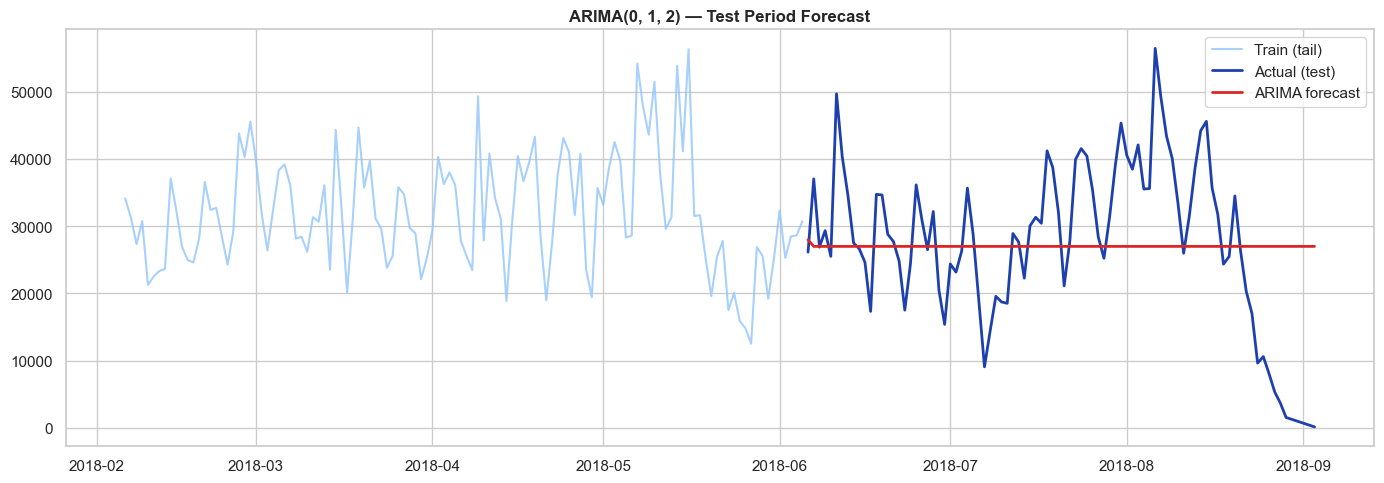

In [22]:
if HAS_PMDARIMA:
    auto_model = pm.auto_arima(
        y_train.values,
        seasonal=False,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        max_p=3,
        max_q=3,
        d=None,
        trace=False,
    )
    order = auto_model.order
    print("auto_arima selected order:", order)
else:
    order = (1, 1, 1)
    print("Using manual ARIMA order:", order)

arima_fit = ARIMA(y_train, order=order).fit()
arima_forecast = arima_fit.forecast(steps=len(y_test))
arima_forecast.index = y_test.index

metrics_rows.append(evaluate(y_test.values, arima_forecast.values, "ARIMA"))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_train.index[-120:], y_train.values[-120:], label="Train (tail)", color="#93c5fd", alpha=0.8)
ax.plot(y_test.index, y_test.values, label="Actual (test)", color="#1e40af", lw=2)
ax.plot(arima_forecast.index, arima_forecast.values, label="ARIMA forecast", color="#dc2626", lw=2)
ax.set_title(f"ARIMA{order} — Test Period Forecast", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


### 6B. Prophet Model

Prophet expects columns `ds` (date) and `y` (target). Weekly/yearly seasonality is enabled when enough history exists.


22:55:43 - cmdstanpy - INFO - Chain [1] start processing
22:55:43 - cmdstanpy - INFO - Chain [1] done processing


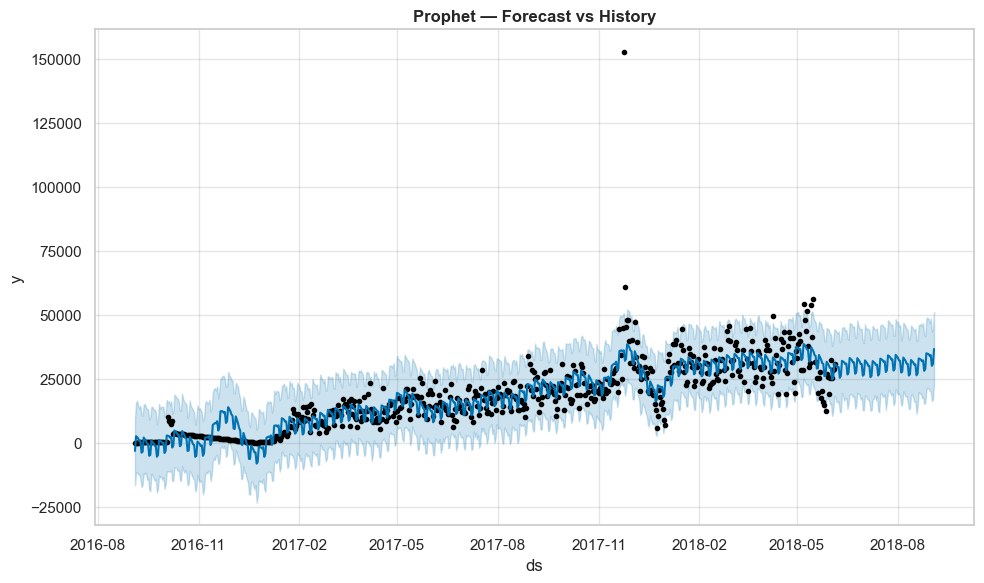

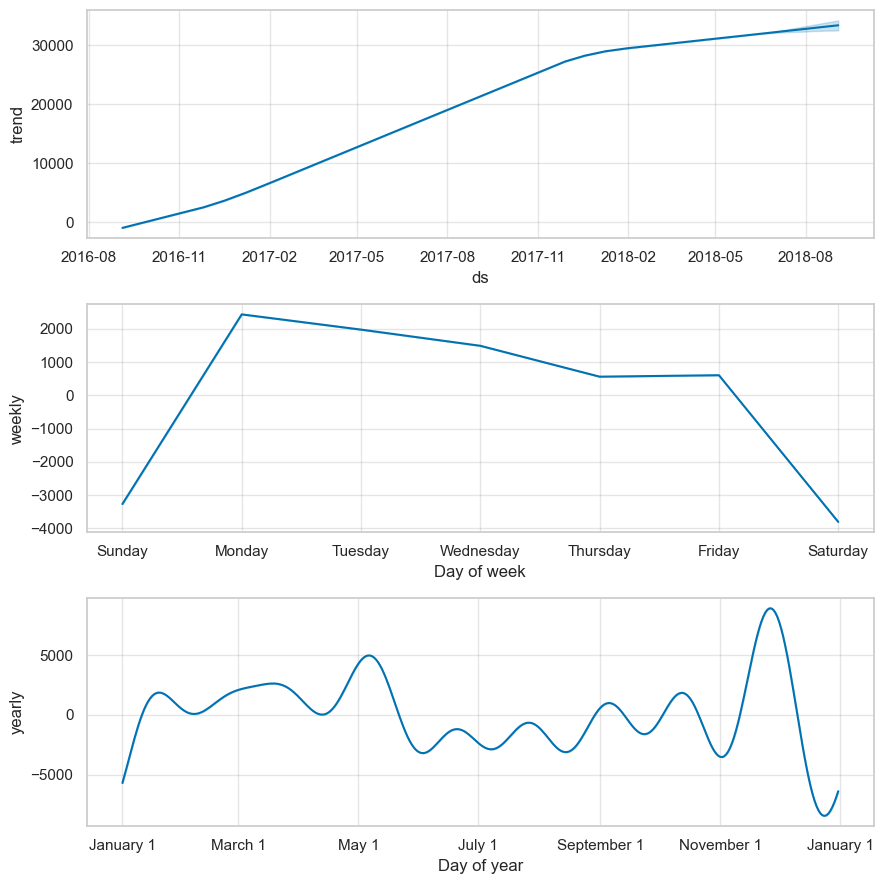

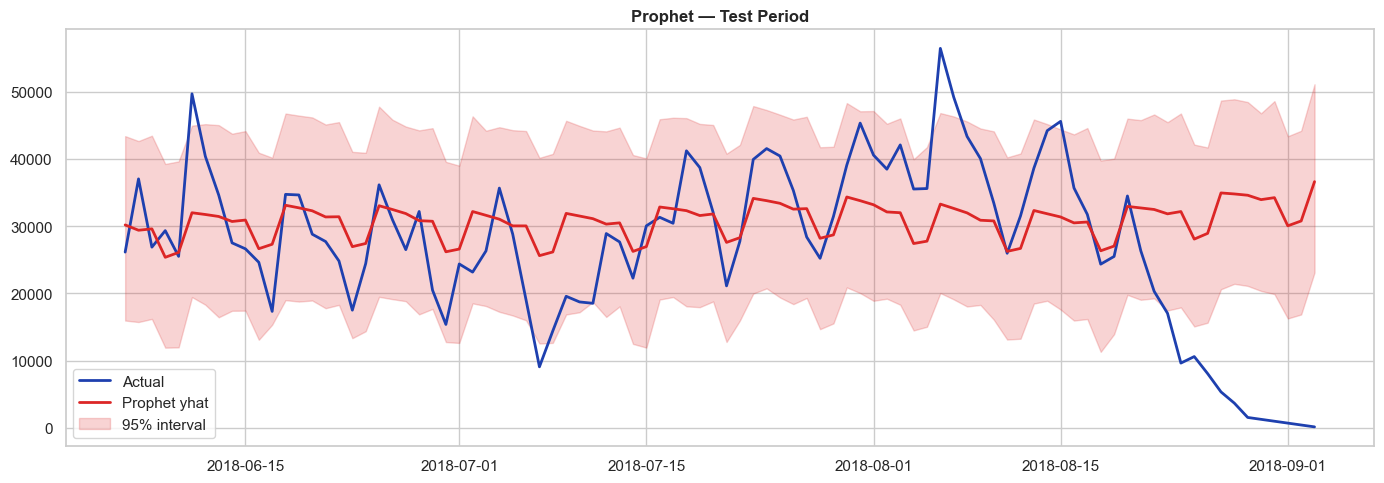

In [23]:
if HAS_PROPHET:
    prophet_train = pd.DataFrame({"ds": y_train.index, "y": y_train.values})
    m = Prophet(
        daily_seasonality=False,
        weekly_seasonality=len(y_train) > 14,
        yearly_seasonality=len(y_train) > 365,
        interval_width=0.95,
    )
    m.fit(prophet_train)

    future = m.make_future_dataframe(periods=len(y_test), freq="D")
    forecast_prophet = m.predict(future)
    prophet_test = forecast_prophet.set_index("ds").loc[y_test.index]

    metrics_rows.append(
        evaluate(y_test.values, prophet_test["yhat"].values, "Prophet")
    )

    fig1 = m.plot(forecast_prophet)
    plt.title("Prophet — Forecast vs History", fontweight="bold")
    plt.tight_layout()
    plt.show()

    fig2 = m.plot_components(forecast_prophet)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(y_test.index, y_test.values, label="Actual", color="#1e40af", lw=2)
    ax.plot(prophet_test.index, prophet_test["yhat"], label="Prophet yhat", color="#dc2626", lw=2)
    ax.fill_between(
        prophet_test.index,
        prophet_test["yhat_lower"],
        prophet_test["yhat_upper"],
        alpha=0.2,
        color="#dc2626",
        label="95% interval",
    )
    ax.set_title("Prophet — Test Period", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    prophet_test = None
    print("Prophet skipped (package not installed).")


## 7. Deep Learning — LSTM

Simple single-layer LSTM on **min–max scaled** revenue with sliding windows. No hyperparameter search.


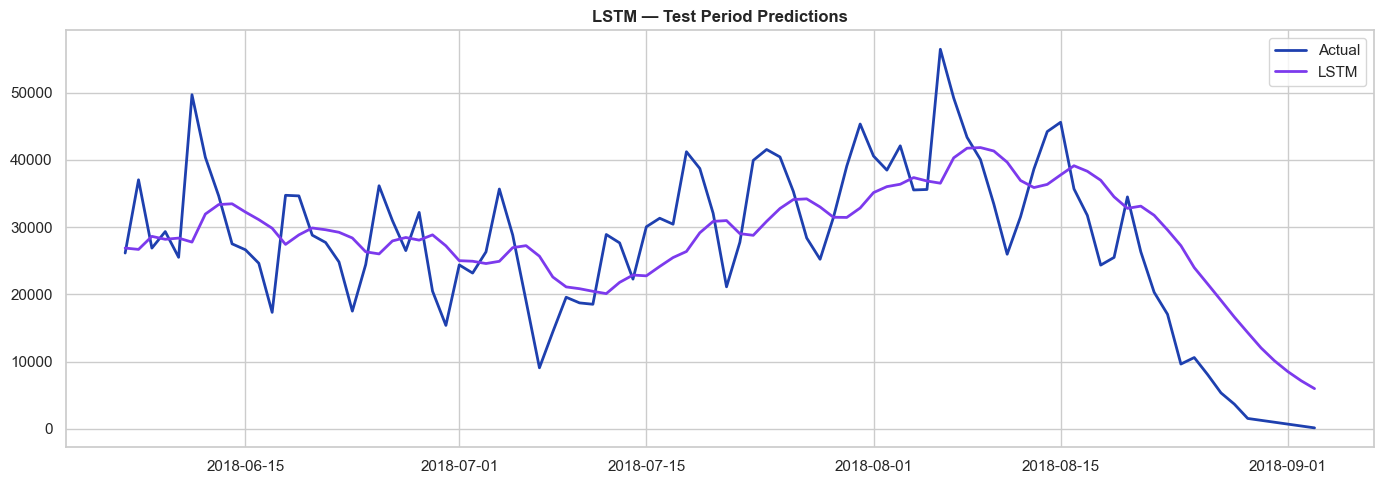

In [24]:
if HAS_TF:
    from sklearn.preprocessing import MinMaxScaler

    def make_sequences(values: np.ndarray, lookback: int):
        X, y = [], []
        for i in range(lookback, len(values)):
            X.append(values[i - lookback : i])
            y.append(values[i])
        return np.array(X), np.array(y)

    LOOKBACK = 30
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    test_scaled = scaler.transform(y_test.values.reshape(-1, 1)).flatten()

    combined = np.concatenate([train_scaled, test_scaled])
    X_test, y_test_scaled = [], []
    train_len = len(train_scaled)
    for i in range(train_len, len(combined)):
        X_test.append(combined[i - LOOKBACK : i])
        y_test_scaled.append(combined[i])
    X_test = np.array(X_test)
    y_test_scaled = np.array(y_test_scaled)

    X_train, y_train_scaled = make_sequences(train_scaled, LOOKBACK)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    lstm_model = keras.Sequential([
        layers.LSTM(32, input_shape=(LOOKBACK, 1)),
        layers.Dense(1),
    ])
    lstm_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse")

    lstm_model.fit(
        X_train,
        y_train_scaled,
        epochs=25,
        batch_size=32,
        verbose=0,
        validation_split=0.1,
        shuffle=False,
    )

    lstm_pred_scaled = lstm_model.predict(X_test, verbose=0).flatten()
    lstm_pred = scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).flatten()

    metrics_rows.append(evaluate(y_test.values, lstm_pred, "LSTM"))

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(y_test.index, y_test.values, label="Actual", color="#1e40af", lw=2)
    ax.plot(y_test.index, lstm_pred, label="LSTM", color="#7c3aed", lw=2)
    ax.set_title("LSTM — Test Period Predictions", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    lstm_pred = None
    print("LSTM skipped (TensorFlow not installed).")


## 8. Rolling Forecast Simulation (Walk-Forward)

One-step-ahead forecasts on the **test** period using a refit-free ARIMA walk-forward loop (fast and illustrative).


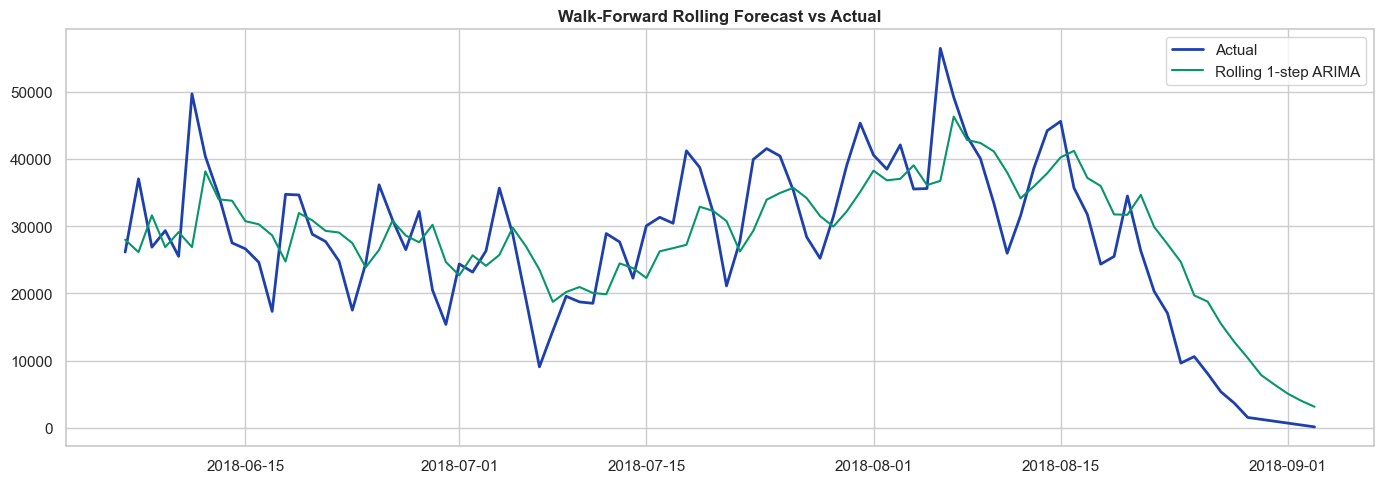

In [25]:
rolling_preds = []
history = list(y_train.values)

for t in range(len(y_test)):
    try:
        model_roll = ARIMA(history, order=order).fit()
        pred = model_roll.forecast(steps=1)[0]
    except Exception:
        pred = history[-1]
    rolling_preds.append(pred)
    history.append(float(y_test.iloc[t]))

rolling_preds = np.array(rolling_preds)
metrics_rows.append(evaluate(y_test.values, rolling_preds, "ARIMA rolling (1-step)"))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_test.index, y_test.values, label="Actual", color="#1e40af", lw=2)
ax.plot(y_test.index, rolling_preds, label="Rolling 1-step ARIMA", color="#059669", lw=1.5)
ax.set_title("Walk-Forward Rolling Forecast vs Actual", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Evaluation Metrics — Model Comparison

Functions **MAE**, **RMSE**, and **MAPE** were applied to each model on the 90-day test set.


In [26]:
summary = pd.DataFrame(metrics_rows).set_index("model")
display(summary)

best_model = summary["RMSE"].idxmin()
print(f"Best model by RMSE on test set: {best_model}")


,MAE,RMSE,MAPE (%)
model,,,
ARIMA,9546.71,12294.58,427.31
Prophet,9101.67,12668.81,538.89
LSTM,6947.50,8460.95,136.28
ARIMA rolling (1-step),5873.52,7331.02,84.89


Best model by RMSE on test set: ARIMA rolling (1-step)


## 10. Forecasting the Next 90 Days

Refit on **full** history using the best-performing approach (falls back to ARIMA if Prophet/LSTM unavailable).


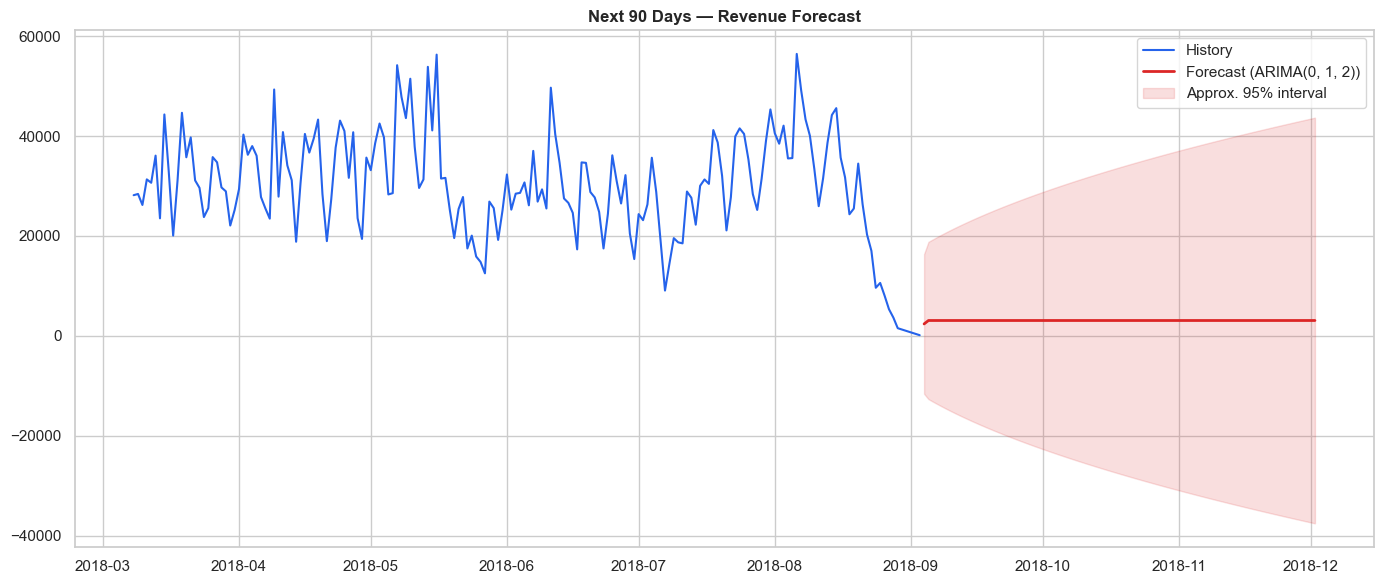

,forecast,lower,upper
2018-09-04,2396.72,-11581.52,16374.97
2018-09-05,3084.41,-12651.70,18820.52
2018-09-06,3084.41,-13149.19,19318.01
2018-09-07,3084.41,-13631.88,19800.70
2018-09-08,3084.41,-14101.01,20269.83
2018-09-09,3084.41,-14557.68,20726.50
2018-09-10,3084.41,-15002.82,21171.64
2018-09-11,3084.41,-15437.26,21606.08
2018-09-12,3084.41,-15861.75,22030.57
2018-09-13,3084.41,-16276.93,22445.75


... 90 days total


In [27]:
full_series = ts["daily_revenue"]
future_idx = pd.date_range(full_series.index[-1] + pd.Timedelta(days=1), periods=FORECAST_HORIZON, freq="D")

if best_model == "Prophet" and HAS_PROPHET:
    pf = pd.DataFrame({"ds": full_series.index, "y": full_series.values})
    m_full = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=len(full_series) > 365,
        interval_width=0.95,
    )
    m_full.fit(pf)
    future_df = m_full.make_future_dataframe(periods=FORECAST_HORIZON, freq="D")
    fc = m_full.predict(future_df).set_index("ds").loc[future_idx]
    future_mean = fc["yhat"]
    future_lower = fc["yhat_lower"]
    future_upper = fc["yhat_upper"]
    model_used = "Prophet"
else:
    fit_full = ARIMA(full_series, order=order).fit()
    fc_arima = fit_full.get_forecast(steps=FORECAST_HORIZON)
    future_mean = fc_arima.predicted_mean
    future_mean.index = future_idx
    conf = fc_arima.conf_int(alpha=0.05)
    future_lower = conf.iloc[:, 0].values
    future_upper = conf.iloc[:, 1].values
    future_lower = pd.Series(future_lower, index=future_idx)
    future_upper = pd.Series(future_upper, index=future_idx)
    model_used = f"ARIMA{order}"

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(full_series.index[-180:], full_series.values[-180:], label="History", color="#2563eb")
ax.plot(future_mean.index, future_mean.values, label=f"Forecast ({model_used})", color="#dc2626", lw=2)
ax.fill_between(
    future_mean.index,
    future_lower,
    future_upper,
    color="#dc2626",
    alpha=0.15,
    label="Approx. 95% interval",
)
ax.set_title(f"Next {FORECAST_HORIZON} Days — Revenue Forecast", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

future_tbl = pd.DataFrame({
    "forecast": future_mean.round(2),
    "lower": future_lower.round(2) if hasattr(future_lower, "round") else future_lower,
    "upper": future_upper.round(2) if hasattr(future_upper, "round") else future_upper,
})
display(future_tbl.head(10))
print(f"... {len(future_tbl)} days total")
